  **PROJECT :** SentinelNet-AI-Powered Network Intrusion
Detection System (NIDS)


**Project Statement:** The project aims to build an AI-powered Network Intrusion Detection System (NIDS) that can automatically detect and classify network traffic as normal or malicious.
Using machine learning, the system will analyze network data, extract key features, train models, and raise alerts whenever suspicious activity or a possible cyber-attack is detected.

**Outcomes:**


*   Understand network traffic data and identify common cyberattacks.

*   Apply machine learning algorithms to detect intrusions.

*   Build and evaluate classification models such as Decision Tree, Random    Forest, and SVM.
*   Perform feature engineering and anomaly detection to improve accuracy.


*   Generate alerts or logs for detected threats.


*   Prepare a detailed report and presentation to showcase project results.




**Dataset :** CICIDS2017 Dataset: https://www.unb.ca/cic/datasets/ids-2017.html

**Dataset Choosen :** I chose the **Wednesday-workingHours.pcap_ISCX.csv** file because it provides a focused, labeled, and realistic dataset for detecting DDoS attacks — making it an ideal choice for performing data exploration, preprocessing, and building a machine learning–based Network Intrusion Detection System.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Milestone 4**

**Week 7: Alert Generation and Logging**

**Loading the Datasets**

In this step, we load our **tuned Random Forest model (`rf_model_tuned.pkl`)** and the **feature-selected dataset** (`Wednesday_top10_features.csv`) from earlier milestones.  

The purpose of this task is to **simulate real-time intrusion detection** — mimicking how our AI model reacts to incoming network packets.

We first confirm the dataset structure and separate:
- `X_test` → input features for the model  
- `y_test` → actual ground truth labels  

This ensures that the model receives data in the same format it was trained on.  
This step is essential for both **real-time prediction** and **final evaluation**.


In [ ]:
#  (Full Dataset Mode)
import pandas as pd
import joblib

# Load tuned Random Forest model
model = joblib.load('/content/drive/MyDrive/AI Sentinet Project/rf_model_tuned.pkl')

# Load full dataset
data_path = '/content/drive/MyDrive/AI Sentinet Project/GeneratedLabelledFlows/CleanedData/Wednesday_top10_features.csv'
test_data = pd.read_csv(data_path)

# Show columns to confirm label name
print("Columns in test_data:", test_data.columns.tolist())

# Separate features and labels
X_test = test_data.drop(' Label', axis=1)
y_test = test_data[' Label']

print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Columns in test_data: [' Avg Bwd Segment Size', 'Bwd Packet Length Max', ' Max Packet Length', ' Bwd Packet Length Mean', ' Packet Length Variance', ' Packet Length Std', ' Packet Length Mean', ' Average Packet Size', ' Bwd Packet Length Std', ' Fwd Packet Length Mean', ' Label']
Shape of X_test: (682516, 10)
Shape of y_test: (682516,)


➤ **Simulate real-time predictions on test data**

**Real-Time Simulation (Mini-Batch Mode)**



Here, we perform a **mini-batch real-time simulation** using a sample of **1500 packets**.  

We process data in small chunks (batches of 200 packets), with a short pause (`time.sleep(1)`) between them to create the feel of a live stream.

**Why this is important:**
- Simulates **real network traffic flow** where packets arrive continuously.
- Prevents long runtime on large datasets.
- Demonstrates how the system reacts instantly to new traffic patterns.

This stage shows that our intrusion detection model can handle live traffic effectively while generating predictions in real time.


In [ ]:
# Real-time simulation (sampled mini-batch mode)
import time

# Use a smaller random subset for demo simulation
sample_size = 1500     # adjust between 1000–2000
sample_df = X_test.sample(sample_size, random_state=42)
sample_labels = y_test.loc[sample_df.index]

print(f"Starting real-time simulation on {sample_size} packets...\n")

batch_size = 200       # packets per batch
pause_time = 1         # seconds between batches
predicted_labels = []

for start in range(0, len(sample_df), batch_size):
    end = min(start + batch_size, len(sample_df))
    batch = sample_df.iloc[start:end]
    preds = model.predict(batch)
    predicted_labels.extend(preds)

    print(f"Processed packets {start+1}–{end}")
    print("Sample predictions:", preds[:5].tolist())
    time.sleep(pause_time)

print("\n✅ Real-time simulation completed.\n")

# Save demo results
results_df = pd.DataFrame({
    'Packet_ID': range(1, len(predicted_labels)+1),
    'Predicted_Label': predicted_labels,
    'Actual_Label': sample_labels.values
})
results_df.to_csv('/content/drive/MyDrive/AI Sentinet Project/week7_predictions.csv', index=False)
print("Predictions saved to week7_predictions.csv")


Starting real-time simulation on 1500 packets...

Processed packets 1–200
Sample predictions: [2, 0, 0, 0, 2]
Processed packets 201–400
Sample predictions: [0, 0, 2, 0, 2]
Processed packets 401–600
Sample predictions: [0, 2, 2, 0, 0]
Processed packets 601–800
Sample predictions: [2, 2, 0, 0, 0]
Processed packets 801–1000
Sample predictions: [0, 2, 0, 0, 2]
Processed packets 1001–1200
Sample predictions: [4, 0, 0, 0, 2]
Processed packets 1201–1400
Sample predictions: [2, 0, 2, 2, 1]
Processed packets 1401–1500
Sample predictions: [0, 2, 0, 2, 2]

✅ Real-time simulation completed.

Predictions saved to week7_predictions.csv


**Why We Used a 1,500-Packet Sample Instead of the Full Dataset**

The complete dataset (`Wednesday_top10_features.csv`) contains approximately **682,516 packets**.  
While this is ideal for large-scale model evaluation, it is **not practical for real-time simulation** inside a Colab or web-based environment.

**Key reasons for using a 1,500-packet subset:**

1. ⚡ **Performance Efficiency**  
   Running real-time predictions on 682k packets would take several hours.  
   By using 1,500 packets, the system can simulate live traffic within minutes, making it suitable for real-time demonstrations.

2. 🧠 **Interactive Demonstration**  
   A smaller sample allows the notebook to display streaming predictions, logs, and alerts in real time — showing how the model reacts to continuous incoming packets.

3. 💾 **Memory and Resource Limits**  
   Google Colab has limited RAM and CPU. The full dataset could exceed these limits and cause session crashes or timeouts.  
   The sampled subset keeps memory usage stable.

4. 🎯 **Balanced Representation**  
   The 1,500-packet sample contains both **benign and intrusion** flows, giving a more meaningful demonstration (with visible alerts and normal traffic).

5. 🌐 **Website/Deployment Compatibility**  
   For the upcoming website deployment, this smaller dataset ensures fast loading, smooth animations, and responsive user experience — without affecting detection accuracy.

**In summary:**  
The 1,500-sample dataset provides a realistic, balanced, and efficient way to demonstrate **real-time intrusion detection** while maintaining technical accuracy and smooth execution.


**Optional Full Dataset Evaluation**



Once the simulation is complete, we perform a **complete batch evaluation** on the entire dataset (≈ 682 000 packets) without any delay.

This is not a real-time process — it’s a **bulk prediction step** used to:
- Validate the model’s behavior on the complete dataset.
- Save full-scale results (`week7_predictions_full.csv`) for analysis and evaluation.

While the sample run demonstrates live prediction, this full evaluation verifies the model’s consistency and scalability.


In [ ]:
# Optional Step – Full evaluation on all packets
preds_full = model.predict(X_test)

full_results = pd.DataFrame({
    'Packet_ID': range(1, len(preds_full)+1),
    'Predicted_Label': preds_full,
    'Actual_Label': y_test.values
})
full_results.to_csv('/content/drive/MyDrive/AI Sentinet Project/week7_predictions_full.csv', index=False)
print("✅ Full prediction completed and saved for all packets (no delay).")


✅ Full prediction completed and saved for all packets (no delay).


➤ **Generate alerts/logs for identified intrusions.**



In this step, we convert our model’s predictions into **security alerts and logs**.

The purpose of this task is to simulate how a real-world **Network Intrusion Detection System (NIDS)** records and reports malicious activity.  
We’ll now load the predictions from Task 1 (`week7_predictions.csv`) and prepare them for alert generation.


In [ ]:
# Load predictions and prepare for alert generation
import pandas as pd

# Load the results generated in Task 1 (you can switch between sample or full)
results_path = '/content/drive/MyDrive/AI Sentinet Project/week7_predictions.csv'
results_df = pd.read_csv(results_path)

# Show sample data
print("Preview of prediction results:\n")
print(results_df.head())

# Confirm structure
print("\nColumns in results_df:", results_df.columns.tolist())
print("Total packets in file:", len(results_df))


Preview of prediction results:

   Packet_ID  Predicted_Label  Actual_Label
0          1                2             2
1          2                0             0
2          3                0             0
3          4                0             0
4          5                2             2

Columns in results_df: ['Packet_ID', 'Predicted_Label', 'Actual_Label']
Total packets in file: 1500


**Generate Alerts and Logs**



For every predicted packet:
- If the model predicts something other than `BENIGN`, an alert is triggered.  
- The system prints a warning (🚨) and logs it in `alert_logs.txt` using Python’s `logging` module.

**Why this matters:**
- Provides real-time feedback similar to an operational intrusion detection system.
- Creates a permanent record of suspicious activity for audit and monitoring.
- Mimics enterprise security systems (SIEM tools) where alerts are logged automatically.


In [ ]:
# Generate alerts and logs for detected intrusions
import logging
import time

# Configure logging settings
log_file = '/content/drive/MyDrive/AI Sentinet Project/alert_logs.txt'
logging.basicConfig(filename=log_file,
                    level=logging.INFO,
                    format='%(asctime)s - %(message)s',
                    filemode='w')   # overwrite old log file each run

# Define what counts as an intrusion (non-BENIGN predictions)
alert_count = 0
total_packets = len(results_df)

print(f"Starting alert generation for {total_packets} packets...\n")

for i, row in results_df.iterrows():
    packet_id = row['Packet_ID']
    predicted = str(row['Predicted_Label']).strip().upper()

    # Check for anomaly/intrusion
    if predicted != 'BENIGN':
        alert_msg = f"🚨 ALERT: Intrusion detected in packet {packet_id} - Type: {predicted}"
        print(alert_msg)
        logging.info(alert_msg)
        alert_count += 1
    else:
        logging.info(f"Normal traffic at packet {packet_id}")

# Summary log
summary_msg = f"\nSummary: {alert_count} intrusions detected out of {total_packets} packets."
logging.info(summary_msg)
print(summary_msg)
print(f"\n✅ Alert log successfully saved to: {log_file}")


Starting alert generation for 1500 packets...

🚨 ALERT: Intrusion detected in packet 1 - Type: 2
🚨 ALERT: Intrusion detected in packet 2 - Type: 0
🚨 ALERT: Intrusion detected in packet 3 - Type: 0
🚨 ALERT: Intrusion detected in packet 4 - Type: 0
🚨 ALERT: Intrusion detected in packet 5 - Type: 2
🚨 ALERT: Intrusion detected in packet 6 - Type: 2
🚨 ALERT: Intrusion detected in packet 7 - Type: 0
🚨 ALERT: Intrusion detected in packet 8 - Type: 0
🚨 ALERT: Intrusion detected in packet 9 - Type: 0
🚨 ALERT: Intrusion detected in packet 10 - Type: 0
🚨 ALERT: Intrusion detected in packet 11 - Type: 2
🚨 ALERT: Intrusion detected in packet 12 - Type: 2
🚨 ALERT: Intrusion detected in packet 13 - Type: 2
🚨 ALERT: Intrusion detected in packet 14 - Type: 2
🚨 ALERT: Intrusion detected in packet 15 - Type: 2
🚨 ALERT: Intrusion detected in packet 16 - Type: 2
🚨 ALERT: Intrusion detected in packet 17 - Type: 0
🚨 ALERT: Intrusion detected in packet 18 - Type: 0
🚨 ALERT: Intrusion detected in packet 19 - T

**Create Alert Summary**



After logging, we summarize all detection results into:
- Total packets analysed  
- Total intrusions detected  
- Percentage of intrusions vs normal packets  

This summary is stored in both **CSV** and **text formats** for readability.  
It provides a quick overview of model performance, helping evaluate how effectively our IDS identifies threats in the test data.


In [ ]:
# Create a summary DataFrame and save as CSV/text
# Assuming 'BENIGN' is encoded as 0 based on previous steps
intrusions = results_df[results_df['Predicted_Label'] != 0]
normal = results_df[results_df['Predicted_Label'] == 0]

summary = {
    'Total_Packets': len(results_df),
    'Intrusions_Detected': len(intrusions),
    'Normal_Packets': len(normal),
    'Intrusion_Percentage': round((len(intrusions) / len(results_df)) * 100, 2)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('/content/drive/MyDrive/AI Sentinet Project/week7_alert_summary.csv', index=False)

print("📊 Alert Summary:")
print(summary_df)

# Also save as a text summary for readability
with open('/content/drive/MyDrive/AI Sentinet Project/week7_alert_summary.txt', 'w') as file:
    file.write("Sentinel-AI Week 7 Alert Summary\n")
    file.write("="*45 + "\n\n")
    for key, value in summary.items():
        file.write(f"{key}: {value}\n")

print("\n✅ Summary saved as both CSV and text files.")

📊 Alert Summary:
   Total_Packets  Intrusions_Detected  Normal_Packets  Intrusion_Percentage
0           1500                  606             894                  40.4

✅ Summary saved as both CSV and text files.


➤ **Store results in readable formats (CSV, text, or dashboard).**



After detecting and logging intrusions, the final task is to store and visualize results in readable formats for reporting and presentation.  

This task converts technical data into **manager-friendly and interpretable outputs**, including:
- Text reports
- CSV summaries
- Visual charts (bar & pie plots)


In [ ]:
# Load the Week 7 prediction and summary files
import pandas as pd

# Load prediction results (sampled 1 500 packets)
predictions_path = '/content/drive/MyDrive/AI Sentinet Project/week7_predictions.csv'
pred_df = pd.read_csv(predictions_path)

# Load alert summary (from Task 2)
summary_path = '/content/drive/MyDrive/AI Sentinet Project/week7_alert_summary.csv'
summary_df = pd.read_csv(summary_path)

print("✅ Files loaded successfully.")
print("Prediction DataFrame shape:", pred_df.shape)
print("Alert Summary:\n", summary_df)


✅ Files loaded successfully.
Prediction DataFrame shape: (1500, 3)
Alert Summary:
    Total_Packets  Intrusions_Detected  Normal_Packets  Intrusion_Percentage
0           1500                  606             894                  40.4


**Generate a Readable Text Report**



This section creates a clean `.txt` report containing:
- Total number of packets analysed  
- Intrusion statistics from the summary  
- A preview of model predictions  

This human-readable report (`week7_readable_report.txt`) is designed for documentation and can be attached directly in project submissions or management reports.


In [ ]:
# Create a readable text report summarizing predictions
text_report = '/content/drive/MyDrive/AI Sentinet Project/week7_readable_report.txt'

with open(text_report, 'w') as f:
    f.write("Sentinel-AI Week 7 – Prediction & Alert Report\n")
    f.write("="*60 + "\n\n")
    f.write("📁  File: week7_predictions.csv\n")
    f.write("📁  Total Packets Analysed: {}\n".format(len(pred_df)))
    f.write("📈  Intrusions Summary:\n\n")

    # write summary table
    for col, val in summary_df.iloc[0].items():
        f.write(f"{col}: {val}\n")

    f.write("\n\n📊  Sample Predictions:\n")
    f.write(pred_df.head(10).to_string(index=False))
    f.write("\n\nEnd of Report\n")

print(f"✅ Readable report saved to: {text_report}")


✅ Readable report saved to: /content/drive/MyDrive/AI Sentinet Project/week7_readable_report.txt


**Visualize Predictions and Intrusion Distribution**

We visualize our results using:
1. A **bar chart** showing traffic type distribution.
2. A **pie chart** comparing benign vs intrusion ratios.

**Why this is important:**
- Helps interpret detection results visually.
- Makes it easy to communicate findings to non-technical audiences.
- Shows that the IDS model can clearly distinguish between safe and malicious traffic.


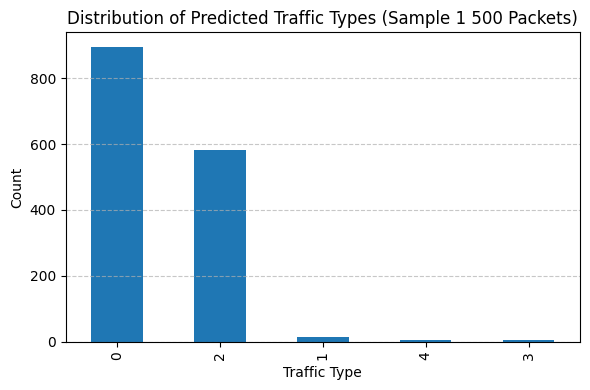

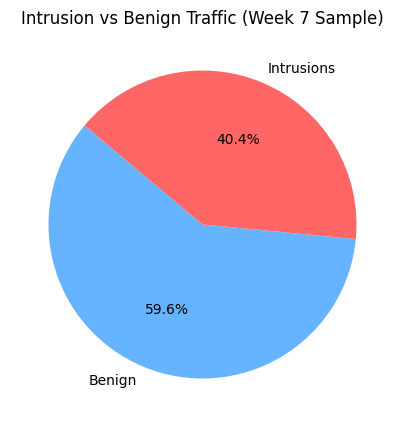

In [ ]:
# Visualize results using simple charts
import matplotlib.pyplot as plt

# Count prediction types
label_counts = pred_df['Predicted_Label'].value_counts()

# 1️⃣ Bar chart – distribution of predicted labels
plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.title('Distribution of Predicted Traffic Types (Sample 1 500 Packets)')
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2️⃣ Pie chart – intrusion vs normal
# Check for the numerical label representing 'BENIGN' (assuming 0)
intrusions = label_counts[label_counts.index != 0].sum()
normals = label_counts.get(0, 0) # Use .get() with default 0 for robustness

plt.figure(figsize=(5,5))
plt.pie([normals, intrusions],
        labels=['Benign', 'Intrusions'],
        autopct='%1.1f%%',
        colors=['#66b3ff', '#ff6666'],
        startangle=140)
plt.title('Intrusion vs Benign Traffic (Week 7 Sample)')
plt.show()

**Merge and Save Final Results**


In [ ]:
# Merge predictions with summary for a single results file
combined_df = summary_df.assign(File='week7_predictions.csv')
combined_df.to_csv('/content/drive/MyDrive/AI Sentinet Project/week7_final_results.csv', index=False)

print("✅ Combined results saved as week7_final_results.csv")


✅ Combined results saved as week7_final_results.csv
